In [186]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [187]:
!which python
!which pip

/Users/wolfidy7/miniforge3/bin/python
/Users/wolfidy7/miniforge3/bin/pip


In [188]:
import sys
!{sys.executable} -m pip install pandas pillow imagehash tqdm matplotlib seaborn opencv-python beautifulsoup4 scipy scikit-image


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
import warnings
import os
import cv2
import hashlib
import imagehash
import scipy.stats as stats


from PIL import Image
from tqdm import tqdm
from collections import Counter

warnings.filterwarnings('ignore')

# CONFIGURATION


In [190]:
IMAGES_PATH = "../images/image_train"
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# RECUPRATION DES IMAGES

In [191]:
# Nombre max d'images à charger
MAX_IMAGES = None  # mettre None pour tout charger

image_paths = []

files = os.listdir(IMAGES_PATH)

for file in files:

    if file.lower().endswith(VALID_EXTENSIONS):

        full_path = os.path.join(IMAGES_PATH, file)

        # Vérifie que c'est bien un fichier
        if os.path.isfile(full_path):

            image_paths.append(full_path)

            # Stop si limite atteinte
            if MAX_IMAGES is not None and len(image_paths) >= MAX_IMAGES:
                break

print(f"Nombre d'images trouvées : {len(image_paths)}")

Nombre d'images trouvées : 84916


# STRUCTURES DE STOCKAGE

In [192]:
results = []

exact_hashes = {}
perceptual_hashes = {}

duplicate_exact = []
duplicate_visual = []

color_stats = []

corrupted_images = []
blank_images = []
grayscale_images = []

# Fonctions utilitaires

In [193]:
#**Hash exact (fichiers identiques)**
def compute_md5(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Détection image vides / noires / blanches

In [194]:
def is_blank_image(img, threshold=5):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.std(gray) < threshold

In [195]:
#**Détection grayscale**
def is_grayscale(img):
    if len(img.shape) < 3:
        return True

    b, g, r = cv2.split(img)

    return (np.allclose(r, g, atol=2) and np.allclose(g, b, atol=2))

# Analyse principale

In [196]:
for path in tqdm(image_paths):

    try:
        # Chargement image
        img_cv = cv2.imread(path)

        if img_cv is None:
            corrupted_images.append(path)
            continue

        height, width = img_cv.shape[:2]
        ratio = width / height

        # Noir/blanc
        blank = is_blank_image(img_cv)

        if blank:
            blank_images.append(path)

        # grayscale
        gray = is_grayscale(img_cv)

        if gray:
            grayscale_images.append(path)

        # Couleurs moyennes
        mean_b = np.mean(img_cv[:, :, 0])
        mean_g = np.mean(img_cv[:, :, 1])
        mean_r = np.mean(img_cv[:, :, 2])

        color_stats.append([mean_r, mean_g, mean_b])

        # Hash exact
        md5 = compute_md5(path)

        if md5 in exact_hashes:
            duplicate_exact.append((path, exact_hashes[md5]))
        else:
            exact_hashes[md5] = path

        # Hash perceptuel (doublons visuels)
        pil_img = Image.open(path)

        phash = str(imagehash.phash(pil_img))

        if phash in perceptual_hashes:
            duplicate_visual.append((path, perceptual_hashes[phash]))
        else:
            perceptual_hashes[phash] = path

        # Stockage stats
        results.append({
            "path": path,
            "width": width,
            "height": height,
            "ratio": ratio,
            "blank": blank,
            "grayscale": gray
        })

    except Exception as e:
        corrupted_images.append(path)

100%|██████████| 84916/84916 [08:56<00:00, 158.31it/s]


In [197]:
# **DataFrame**
df = pd.DataFrame(results)

print(df.head())

                                                path  width  height  ratio  \
0  ../images/image_train/image_1174594490_product...    500     500    1.0   
1  ../images/image_train/image_1172460449_product...    500     500    1.0   
2  ../images/image_train/image_1313553701_product...    500     500    1.0   
3  ../images/image_train/image_1008107210_product...    500     500    1.0   
4  ../images/image_train/image_1190251689_product...    500     500    1.0   

   blank  grayscale  
0  False      False  
1  False      False  
2  False      False  
3  False      False  
4  False      False  


# Résumé global

In [198]:

def print_image_list(label, paths, max_display=None):
    print(f"\n--- {label} ({len(paths)}) ---")
    items = paths if max_display is None else paths[:max_display]
    for p in items:
        print(f"  {os.path.basename(p)}")
    if max_display and len(paths) > max_display:
        print(f"  ... et {len(paths) - max_display} autres")

print("===== DATASET SUMMARY =====")
print(f"Total images analysées : {len(df)}")
print(f"Images corrompues      : {len(corrupted_images)}")
print(f"Images vides/noires    : {len(blank_images)}")
print(f"Images grayscale       : {len(grayscale_images)}")
print(f"Duplicates exacts      : {len(duplicate_exact)}")
print(f"Duplicates visuels     : {len(duplicate_visual)}")

# if corrupted_images:
#     print_image_list("Images corrompues", corrupted_images)

# if blank_images:
#     print_image_list("Images vides/noires", blank_images)

# if grayscale_images:
#     print_image_list("Images grayscale", grayscale_images)

# if duplicate_exact:
#     print(f"\n--- Duplicates exacts ({len(duplicate_exact)}) ---")
#     for path, original in duplicate_exact:
#         print(f"  {os.path.basename(path)}  <->  {os.path.basename(original)}")

# if duplicate_visual:
#     print(f"\n--- Duplicates visuels ({len(duplicate_visual)}) ---")
#     for path, original in duplicate_visual:
#         print(f"  {os.path.basename(path)}  <->  {os.path.basename(original)}")


===== DATASET SUMMARY =====
Total images analysées : 84916
Images corrompues      : 0
Images vides/noires    : 50
Images grayscale       : 961
Duplicates exacts      : 5692
Duplicates visuels     : 7590


# Visualisation des données (images vides/noires/blanches)

In [199]:
import scipy.stats as stats

# 1. Ajout des statistiques de couleur au DataFrame
# Comme color_stats a été rempli dans la même boucle que results, l'ordre correspond.
df['mean_r'] = [c[0] for c in color_stats]
df['mean_g'] = [c[1] for c in color_stats]
df['mean_b'] = [c[2] for c in color_stats]

# Calcul de l'intensité moyenne globale de l'image (moyenne des 3 canaux)
df['mean_intensity'] = df[['mean_r', 'mean_g', 'mean_b']].mean(axis=1)

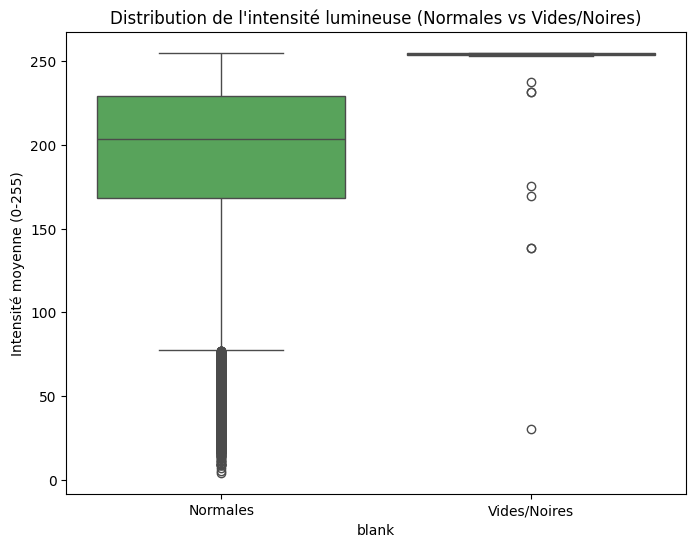

On observe que la répartition de l'intensité lumineuse moyenne des images vides/noires S'ÉCRASE sur des 
valeurs HAUTES (envrion 200-255), ce qui est cohérent avec des images très claires ou blanches (vides).


In [200]:
# 1. Comparaison visuelle de l'intensité moyenne
plt.figure(figsize=(8, 6))
sns.boxplot(x='blank', y='mean_intensity', data=df, palette=['#4CAF50', '#F44336'])
plt.xticks([0, 1], ['Normales', 'Vides/Noires'])
plt.title("Distribution de l'intensité lumineuse (Normales vs Vides/Noires)")
plt.ylabel("Intensité moyenne (0-255)")
plt.show()

print("On observe que la répartition de l'intensité lumineuse moyenne des images vides/noires S'ÉCRASE sur des \nvaleurs HAUTES (envrion 200-255), ce qui est cohérent avec des images très claires ou blanches (vides).")

# Le Test Statistique (Test T de Welch)

Puisque nous voulons comparer les moyennes de deux groupes indépendants ("Images normales" vs "Images vides"), et que ces deux groupes ont des tailles et des variances très différentes (les images noires n'ont quasiment aucune variance, contrairement aux normales), le Test T de Welch (Welch's t-test) est le plus approprié. 

(L'ANOVA ferait la même chose, mais est plutôt conçue pour 3 groupes ou plus).

**Hypothèse Nulle ($H_0$)** : Les images "vides" ont la même intensité moyenne que les images "normales" (la règle de tri n'a aucun sens).

**Hypothèse Alternative ($H_1$)** : Les intensités moyennes sont significativement différentes.

In [201]:
# 2. Séparation des deux échantillons
intensites_normales = df[df['blank'] == False]['mean_intensity']
intensites_vides = df[df['blank'] == True]['mean_intensity']

print(f"Taille de l'échantillon 'Normales' : {len(intensites_normales)}")
print(f"Taille de l'échantillon 'Vides'    : {len(intensites_vides)}")

# On effectue le test seulement s'il y a des images vides
if len(intensites_vides) > 0:
    # Test T de Welch (equal_var=False car les variances sont clairement différentes)
    t_stat, p_value = stats.ttest_ind(intensites_normales, intensites_vides, equal_var=False)
    
    print("\n--- RÉSULTATS DU TEST STATISTIQUE (Test T de Welch) ---")
    print(f"Statistique T : {t_stat:.4f}")
    print(f"P-value       : {p_value:.4e}")
    
    # Interprétation avec un seuil de confiance de 95% (alpha = 0.05)
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion : La p-value est inférieure à 0.05.")
        print("=> On REJETTE l'hypothèse nulle.")
        print("=> Les images identifiées comme 'vides' ont une distribution de couleurs STATISTIQUEMENT DIFFÉRENTE du reste du dataset. Le filtre est valide !")
    else:
        print("\nConclusion : La p-value est supérieure à 0.05.")
        print("=> On NE PEUT PAS rejeter l'hypothèse nulle.")
        print("=> La différence n'est pas statistiquement significative, le seuil du filtre 'is_blank_image' est peut-être trop large ou inadapté.")
else:
    print("\nAucune image vide/noire détectée, le test statistique n'est pas nécessaire.")

Taille de l'échantillon 'Normales' : 84866
Taille de l'échantillon 'Vides'    : 50

--- RÉSULTATS DU TEST STATISTIQUE (Test T de Welch) ---
Statistique T : -7.7537
P-value       : 4.5214e-10

Conclusion : La p-value est inférieure à 0.05.
=> On REJETTE l'hypothèse nulle.
=> Les images identifiées comme 'vides' ont une distribution de couleurs STATISTIQUEMENT DIFFÉRENTE du reste du dataset. Le filtre est valide !


# Visualisation des données (images similaires/dupliquées)


**Calcul du SSIM et Graphique de stabilité**

Nous allons calculer le SSIM sur un échantillon des doublons visuels et utiliser un Violin Plot (graphique en violon). 

C'est le meilleur choix ici car il combine une boîte à moustaches (pour voir la médiane et les quartiles) 
et une courbe de densité pour visualiser la "stabilité" (la concentration des scores autour de 1).

Calcul du SSIM: 100%|██████████| 150/150 [00:02<00:00, 70.70it/s]


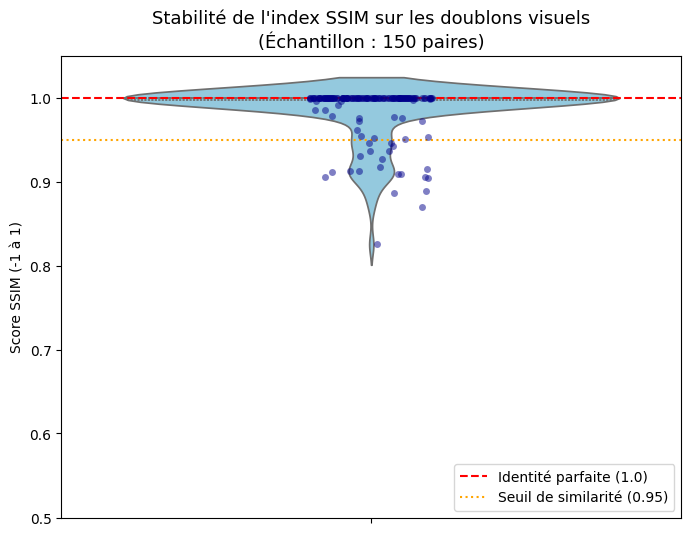

Nous constatons une concentration des scores SSIM autour de 0.95 et plus (surtout autour de 1), ce qui confirme que les images détectées par l'algorithme pHash sont bien quasi-identiques.


In [202]:
import random
from skimage.metrics import structural_similarity as ssim

# **CALCUL DU SSIM SUR LES DOUBLONS VISUELS**

def get_ssim(path1, path2):
    # Lecture en niveaux de gris (recommandé pour le SSIM)
    img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
    
    if img1 is None or img2 is None:
        return None
        
    # Le SSIM nécessite des images de la même dimension
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
        
    # Calcul du score (win_size ajusté si les images sont petites)
    min_dim = min(img1.shape)
    win_size = min(7, min_dim) if min_dim < 7 else 7
    
    score, _ = ssim(img1, img2, full=True, win_size=win_size, data_range=255)
    return score

# Échantillonnage pour éviter des temps de calcul trop longs (max 150 paires)
sample_size = min(150, len(duplicate_visual))
sampled_duplicates = random.sample(duplicate_visual, sample_size) if duplicate_visual else []

ssim_scores = []
for p1, p2 in tqdm(sampled_duplicates, desc="Calcul du SSIM"):
    score = get_ssim(p1, p2)
    if score is not None:
        ssim_scores.append(score)

# **VISUALISATION : STABILITÉ DU SSIM**
if ssim_scores:
    plt.figure(figsize=(8, 6))
    
    # Violin plot pour la densité globale
    sns.violinplot(y=ssim_scores, color="skyblue", inner="quartile")
    
    # Strip plot pour voir chaque paire individuellement par-dessus
    sns.stripplot(y=ssim_scores, color="darkblue", alpha=0.5, jitter=True)
    
    plt.axhline(1.0, color='red', linestyle='--', label='Identité parfaite (1.0)')
    plt.axhline(0.95, color='orange', linestyle=':', label='Seuil de similarité (0.95)')
    
    plt.title(f"Stabilité de l'index SSIM sur les doublons visuels\n(Échantillon : {len(ssim_scores)} paires)", fontsize=13)
    plt.ylabel("Score SSIM (-1 à 1)")
    plt.ylim(min(0.5, min(ssim_scores) - 0.1), 1.05)
    plt.legend(loc="lower right")
    plt.show()
else:
    print("Pas assez de données pour calculer le SSIM.")

print("Nous constatons une concentration des scores SSIM autour de 0.95 et plus (surtout autour de 1), ce qui confirme que les images détectées par l'algorithme pHash sont bien quasi-identiques.")

# Test Statistique de Similarité

Nous allons utiliser un Test T pour échantillon unique (One-Sample T-test).

Nous testons l'hypothèse que la vraie moyenne des similarités est très élevée (proche de l'identité).

**Hypothèse Nulle ($H_0$)** : Le SSIM moyen est supérieur ou égal à $0.95$ (Les images sont visuellement identiques/très similaires).

**Hypothèse Alternative ($H_1$)** : Le SSIM moyen est strictement inférieur à $0.95$ (Le filtre pHash a fait des erreurs et a groupé des images trop différentes).

In [203]:
# **TEST STATISTIQUE : VALIDATION DE LA SIMILARITÉ**

if ssim_scores:
    # Seuil de "quasi-identité" visuelle
    threshold = 0.95 
    
    # Test t à un échantillon (alternative='less' car on veut voir si la moyenne est significativement en-dessous du seuil)
    # Note: L'argument alternative nécessite scipy 1.6.0+
    t_stat, p_value = stats.ttest_1samp(ssim_scores, popmean=threshold, alternative='less')
    
    mean_ssim = np.mean(ssim_scores)
    
    print("--- RÉSULTATS DU TEST STATISTIQUE (One-Sample T-Test) ---")
    print(f"Moyenne SSIM de l'échantillon : {mean_ssim:.4f}")
    print(f"Statistique T                 : {t_stat:.4f}")
    print(f"P-value                       : {p_value:.4e}")
    
    alpha = 0.05
    if p_value < alpha:
        print("\nConclusion : La p-value est inférieure à 0.05.")
        print("=> On REJETTE l'hypothèse nulle.")
        print(f"=> Le SSIM moyen est significativement inférieur à {threshold}. Le seuil pHash regroupe des images qui comportent des différences structurelles notables.")
    else:
        print("\nConclusion : La p-value est supérieure à 0.05.")
        print("=> On NE PEUT PAS rejeter l'hypothèse nulle.")
        print(f"=> Statistiquement, le SSIM des doublons est bien concentré à {threshold} ou plus.")
        print("=> Validation : Les images détectées par l'algorithme pHash sont confirmées comme quasi-identiques.")
else:
    print("Pas de données SSIM à tester.")

--- RÉSULTATS DU TEST STATISTIQUE (One-Sample T-Test) ---
Moyenne SSIM de l'échantillon : 0.9847
Statistique T                 : 12.9012
P-value                       : 1.0000e+00

Conclusion : La p-value est supérieure à 0.05.
=> On NE PEUT PAS rejeter l'hypothèse nulle.
=> Statistiquement, le SSIM des doublons est bien concentré à 0.95 ou plus.
=> Validation : Les images détectées par l'algorithme pHash sont confirmées comme quasi-identiques.


In [204]:
# Visualisation globale et dimensionnelle

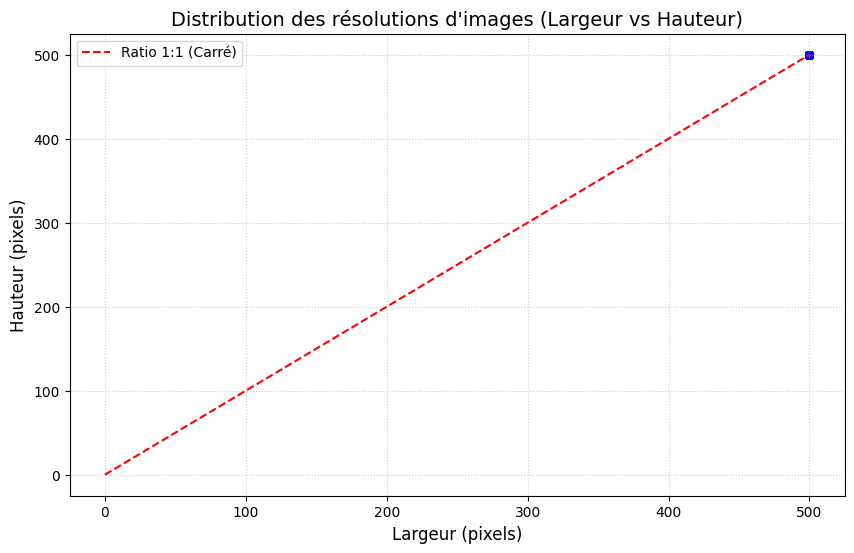

In [205]:
# 1. Distribution des résolutions (Largeur vs Hauteur)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='width', y='height', data=df, alpha=0.1, color='blue', edgecolor=None)

plt.title("Distribution des résolutions d'images (Largeur vs Hauteur)", fontsize=14)
plt.xlabel("Largeur (pixels)", fontsize=12)
plt.ylabel("Hauteur (pixels)", fontsize=12)

# Ajout d'une ligne de ratio 1:1 (carré)
max_val = max(df['width'].max(), df['height'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label="Ratio 1:1 (Carré)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

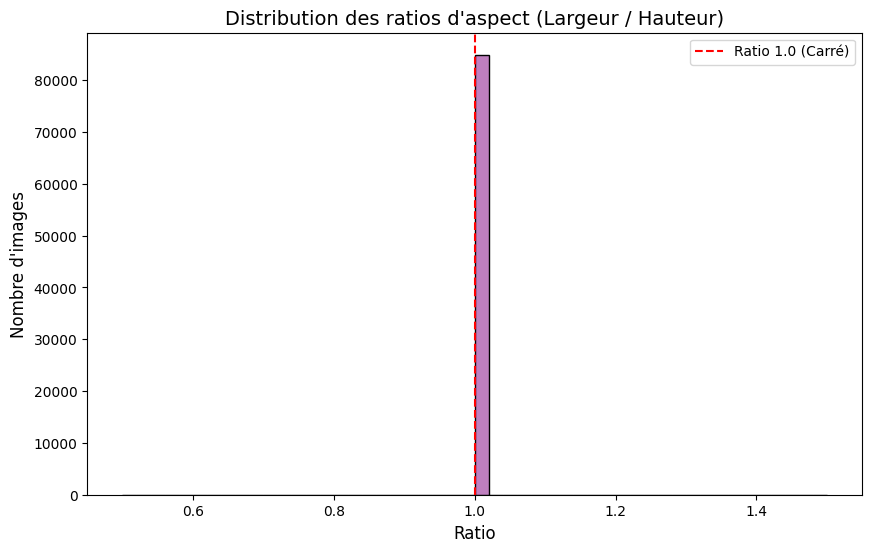

In [206]:
# 2. Distribution des ratios
plt.figure(figsize=(10, 6))
sns.histplot(df['ratio'], bins=50, kde=True, color='purple')

plt.title("Distribution des ratios d'aspect (Largeur / Hauteur)", fontsize=14)
plt.xlabel("Ratio", fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)

plt.axvline(1.0, color='red', linestyle='--', label='Ratio 1.0 (Carré)')
plt.legend()

plt.show()

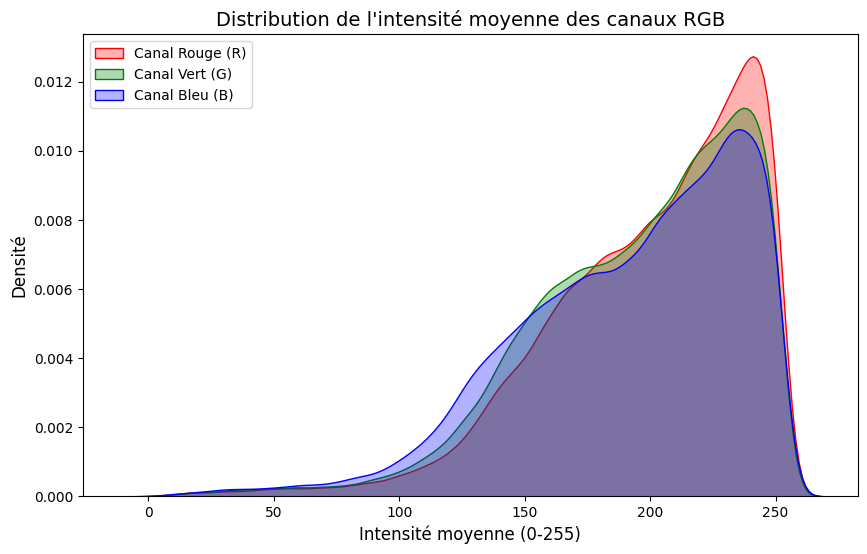

In [207]:
# 3. Colorimétrie globale (RGB)
plt.figure(figsize=(10, 6))

sns.kdeplot(df['mean_r'], color='red', label='Canal Rouge (R)', fill=True, alpha=0.3)
sns.kdeplot(df['mean_g'], color='green', label='Canal Vert (G)', fill=True, alpha=0.3)
sns.kdeplot(df['mean_b'], color='blue', label='Canal Bleu (B)', fill=True, alpha=0.3)

plt.title("Distribution de l'intensité moyenne des canaux RGB", fontsize=14)
plt.xlabel("Intensité moyenne (0-255)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend()

plt.show()

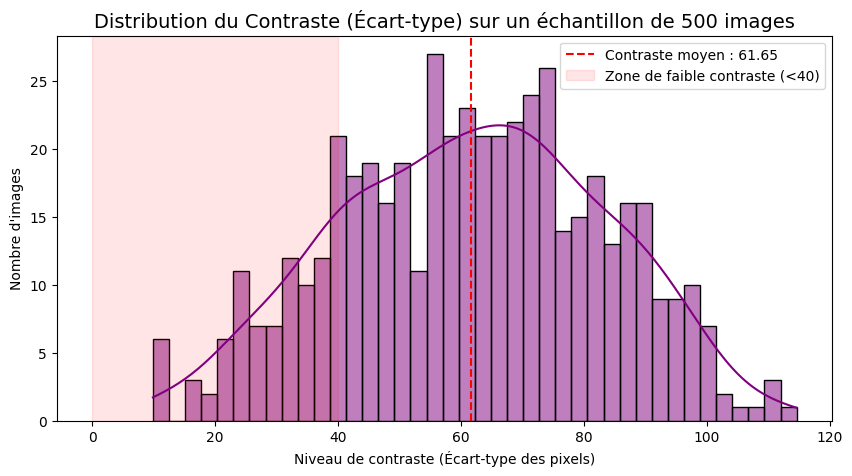

Pourcentage d'images à faible contraste (<40) : 17.40%


In [209]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# On prend un échantillon aléatoire (ex: 500 images) pour l'analyse
sample_size = min(500, len(df))
sample_paths = df['path'].sample(n=sample_size, random_state=42).tolist()

contrast_metrics = []

for path in sample_paths:
    # Lecture en niveaux de gris (suffisant pour analyser la lumière/contraste)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        # L'écart-type des pixels est une excellente mesure du contraste global
        contrast = img.std()
        contrast_metrics.append({'path': path, 'contrast': contrast})

df_contrast = pd.DataFrame(contrast_metrics)

# --- VISUALISATION DE LA DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(df_contrast['contrast'], bins=40, kde=True, color='purple')

# Ajout de la moyenne
mean_contrast = df_contrast['contrast'].mean()
plt.axvline(mean_contrast, color='red', linestyle='--', label=f'Contraste moyen : {mean_contrast:.2f}')

# Zone empirique de "faible contraste" (généralement < 40)
plt.axvspan(0, 40, color='red', alpha=0.1, label='Zone de faible contraste (<40)')

plt.title(f"Distribution du Contraste (Écart-type) sur un échantillon de {sample_size} images", fontsize=14)
plt.xlabel("Niveau de contraste (Écart-type des pixels)")
plt.ylabel("Nombre d'images")
plt.legend()
plt.show()

print(f"Pourcentage d'images à faible contraste (<40) : {(len(df_contrast[df_contrast['contrast'] < 40]) / len(df_contrast)) * 100:.2f}%")

Image sélectionnée : ../images/image_train/image_1233288834_product_1832994874.jpg (Contraste: 9.89)


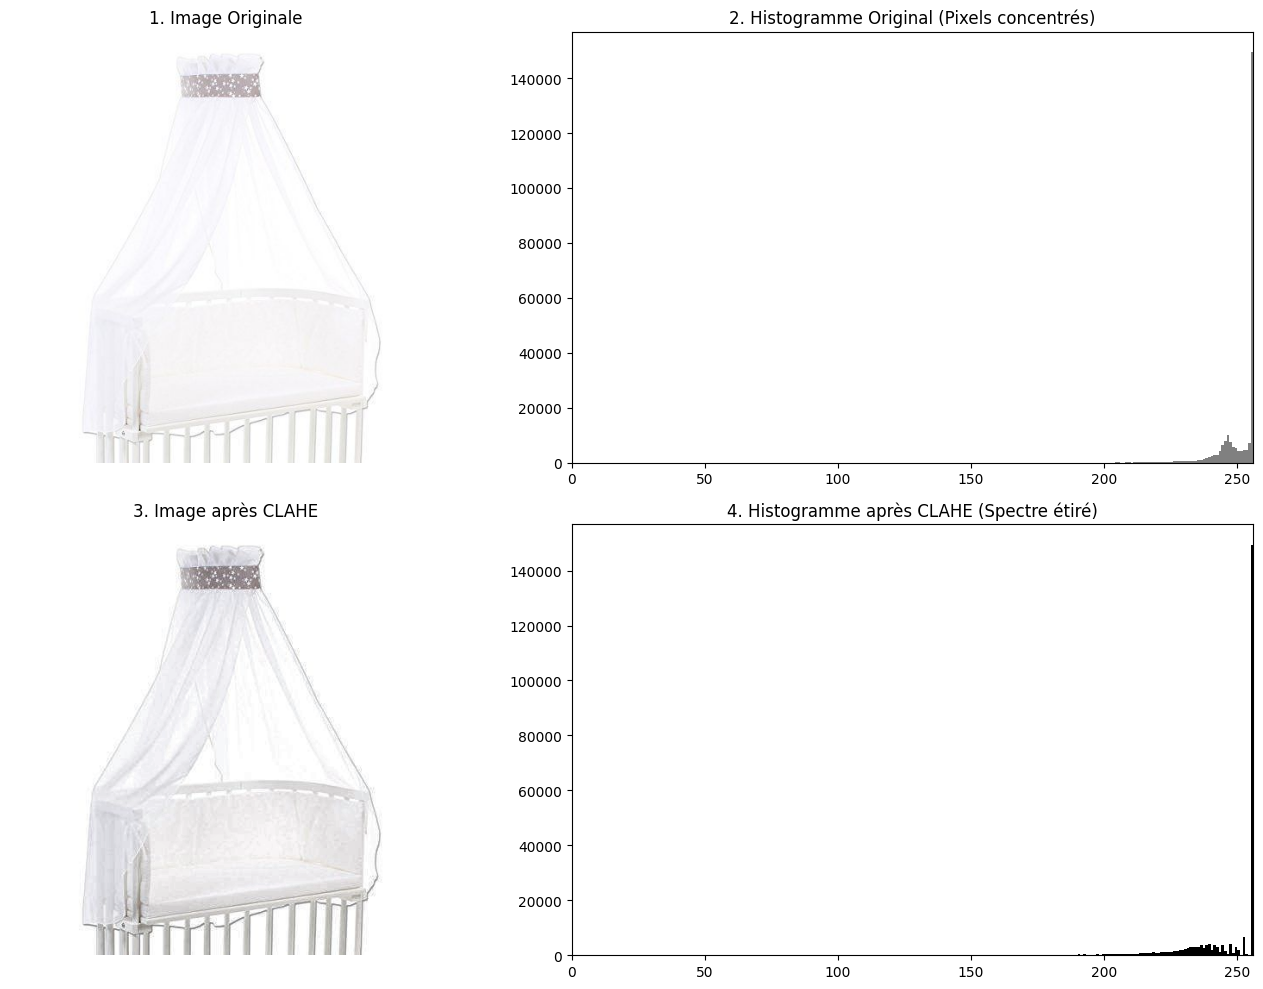

In [210]:
# Isoler une image avec un très faible contraste
low_contrast_images = df_contrast.sort_values('contrast')
worst_image_path = low_contrast_images.iloc[0]['path']
worst_contrast_val = low_contrast_images.iloc[0]['contrast']

print(f"Image sélectionnée : {worst_image_path} (Contraste: {worst_contrast_val:.2f})")

# Charger l'image en couleurs (BGR vers RGB) et en niveaux de gris
img_bgr = cv2.imread(worst_image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# --- 1. Appliquer le CLAHE sur l'image en niveaux de gris (pour la démo mathématique) ---
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_gray_clahe = clahe.apply(img_gray)

# --- 2. Appliquer le CLAHE sur l'image en couleurs (Plus pertinent pour ton modèle) ---
# Il faut convertir en espace colorimétrique LAB, égaliser la luminosité (L), et revenir en RGB
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
l_clahe = clahe.apply(l)
lab_clahe = cv2.merge((l_clahe, a, b))
img_rgb_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

# --- VISUALISATION AVANT / APRÈS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Originale
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Image Originale", fontsize=12)
axes[0, 0].axis('off')

# Histogramme original (sur le niveau de gris pour simplifier)
axes[0, 1].hist(img_gray.ravel(), bins=256, range=[0,256], color='gray')
axes[0, 1].set_title("2. Histogramme Original (Pixels concentrés)", fontsize=12)
axes[0, 1].set_xlim([0, 256])

# Après CLAHE
axes[1, 0].imshow(img_rgb_clahe)
axes[1, 0].set_title("3. Image après CLAHE", fontsize=12)
axes[1, 0].axis('off')

# Histogramme CLAHE
axes[1, 1].hist(img_gray_clahe.ravel(), bins=256, range=[0,256], color='black')
axes[1, 1].set_title("4. Histogramme après CLAHE (Spectre étiré)", fontsize=12)
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

In [208]:
# Marqueurs de doublons
df['is_duplicate_exact'] = df['path'].isin([p[0] for p in duplicate_exact])
df['is_duplicate_visual'] = df['path'].isin([p[0] for p in duplicate_visual])
df['is_duplicate'] = df['is_duplicate_exact'] | df['is_duplicate_visual']

# Sauvegarder en raw_df (données brutes avec marqueurs)
import os
raw_df = df.copy()

output_dir = os.path.join('..', 'data')
os.makedirs(output_dir, exist_ok=True)
raw_df.to_csv(os.path.join(output_dir, 'raw_df.csv'), index=False)
print(f"raw_df saved ({len(raw_df)} rows)")


raw_df saved (84916 rows)
